In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('/rhome/sawale/indus_traning/mlm-fine-tuning/mlm')
sys.path.append('/rhome/sawale/indus_traning/mlm-fine-tuning/mlm/embedding_analysis/foreign_implementations/svcca')

In [3]:
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import AutoModel, AutoTokenizer, pipeline
import torch
import torch.nn.functional as F
from dotenv import load_dotenv
load_dotenv()
from huggingface_hub import login
login(os.getenv("HUGGINGFACE_TOKEN"))

from preprocess_data import get_dataset
import cca_core

def set_seed(seed=42) -> None:
    """Set all seeds to make results reproducible (deterministic mode).
    When seed is a false-y value or not supplied, disables deterministic mode."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

/rhome/sawale/indus_traning/mlm-fine-tuning/.venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load dataset

In [4]:
config_path = "../config.json"
with open(config_path, "r") as file:
    config = json.load(file)
data_src = "local"
n_rows = None

dataset = get_dataset(config["input"]["dataset"], data_src, n_rows)
print(dataset["test"].shape)

(12124, 13)


# Load the model and tokenizer

In [5]:
# Load model or dataset
new_model_name = "nasa-impact/indus-sde-v0.1"
old_model_name = "nasa-impact/nasa-smd-ibm-v0.1"

# Step 1: Load the model and tokenizer
model_names = {"old_model_name": "nasa-impact/nasa-smd-ibm-v0.1", "new_model_name": "nasa-impact/indus-sde-v0.1"}
models = {mn:AutoModel.from_pretrained(hf_model_name, output_hidden_states=True) for mn, hf_model_name in model_names.items()}
tokenizers = {mn:AutoTokenizer.from_pretrained(hf_model_name) for mn, hf_model_name in model_names.items()}
embeddings = {mn:{} for mn in model_names.keys()}

Some weights of RobertaModel were not initialized from the model checkpoint at nasa-impact/nasa-smd-ibm-v0.1 and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at nasa-impact/indus-sde-v0.1 and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Generate embeddings

In [6]:
batch_size = 16  # Adjust based on GPU memory

# Iterate through the dataset in batches
with torch.no_grad():
    for i in tqdm(range(0, len(dataset["test"]), batch_size)):
        # Extract a batch from the dataset by slicing
        batch = dataset["test"][i:i + batch_size]

        # Generate embeddings for each model
        for mn, model in models.items():
            inputs = tokenizers.get(mn)(
                batch["text"],  # Assuming the dataset has a "text" column
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=500
            )
            with torch.no_grad():
                output = model(**inputs)
            hidden_states = output.hidden_states  # Tuple of Shape: (13, batch_size, seq_len, hidden_dim). 13 for all embedding inclusing input to first layer
            # Compute mean across tokens for each layer
            mean_token_representations = [layer.mean(dim=1) for layer in hidden_states]  # Shape: (13, batch_size, hidden_dim)

            # loop for layers
            for li, layer in enumerate(mean_token_representations):
                if embeddings[mn].get(li) is None:
                    embeddings[mn][li] = layer.cpu()
                else:
                    embeddings[mn][li] = torch.cat((embeddings[mn][li], layer.cpu()), dim=0)    
        
torch.save(embeddings, 'hidden_state_model_embeddings.pt')

  0%|          | 0/758 [00:00<?, ?it/s]

100%|██████████| 758/758 [21:47<00:00,  1.72s/it]


In [6]:
# load the embedding if there is embedding file
# check if the file exists first
path = 'hidden_state_model_embeddings.pt'
if os.path.exists(path):
    embeddings = torch.load(path)

/tmp/ipykernel_1426657/2980275879.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  embeddings = torch.load(path)


In [9]:
# embeddings["new_model_name"][0][1]

# Helper Methods

In [8]:
def plot_cca_similarity(cca_values, factor_name = "CCA", n_columns=3):
    response_mean_ccas = {}
    n_layers = len(cca_values)
    n_rows = int(np.ceil(n_layers / float(n_columns)))

    # Create subplots 
    fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*5 + 2, n_rows*4 + 2))

    # Flatten axes array for easy iteration
    axes = axes.flatten()

    
    for i in cca_values.keys(): # loops though layers
        mean_ccas = ""
        response_mean_ccas[i] = {}
        for _n in cca_values[i].keys(): # loops through results and names
            response_mean_ccas[i][_n] = round(np.mean(cca_values[i][_n]['cca_coef1']),2)
            axes[i].plot(cca_values[i][_n]["cca_coef1"], label=_n)
            mean_ccas += f"\nMean_{factor_name}({_n}): {response_mean_ccas[i][_n]}"


        axes[i].set_xlabel(f"Sorted {factor_name} Correlation Coeff Idx")
        axes[i].set_ylabel(f"{factor_name} Correlation Coefficient Value")
        axes[i].set_title(f'$\\bf{{{factor_name} for Layer {i}}}$ {mean_ccas}', fontsize=10)
        axes[i].legend()  # Show legend
        axes[i].grid(True)  # Enable grid

    
    # Hide empty subplots
    for i in range(n_layers, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    response_mean_ccas = {k: {i: response_mean_ccas[i][k] for i in response_mean_ccas} 
                          for k in response_mean_ccas[next(iter(response_mean_ccas))]}
    return response_mean_ccas




def find_pcomponents_for_variance(s_values, threshold=0.9):
    cumulative = 0.0
    total_values = sum(s_values)
    for i, s in enumerate(s_values):
        cumulative += s
        if cumulative/total_values >= threshold:
            return i + 1

# Using CCA (Canonical Correlation Analysis)

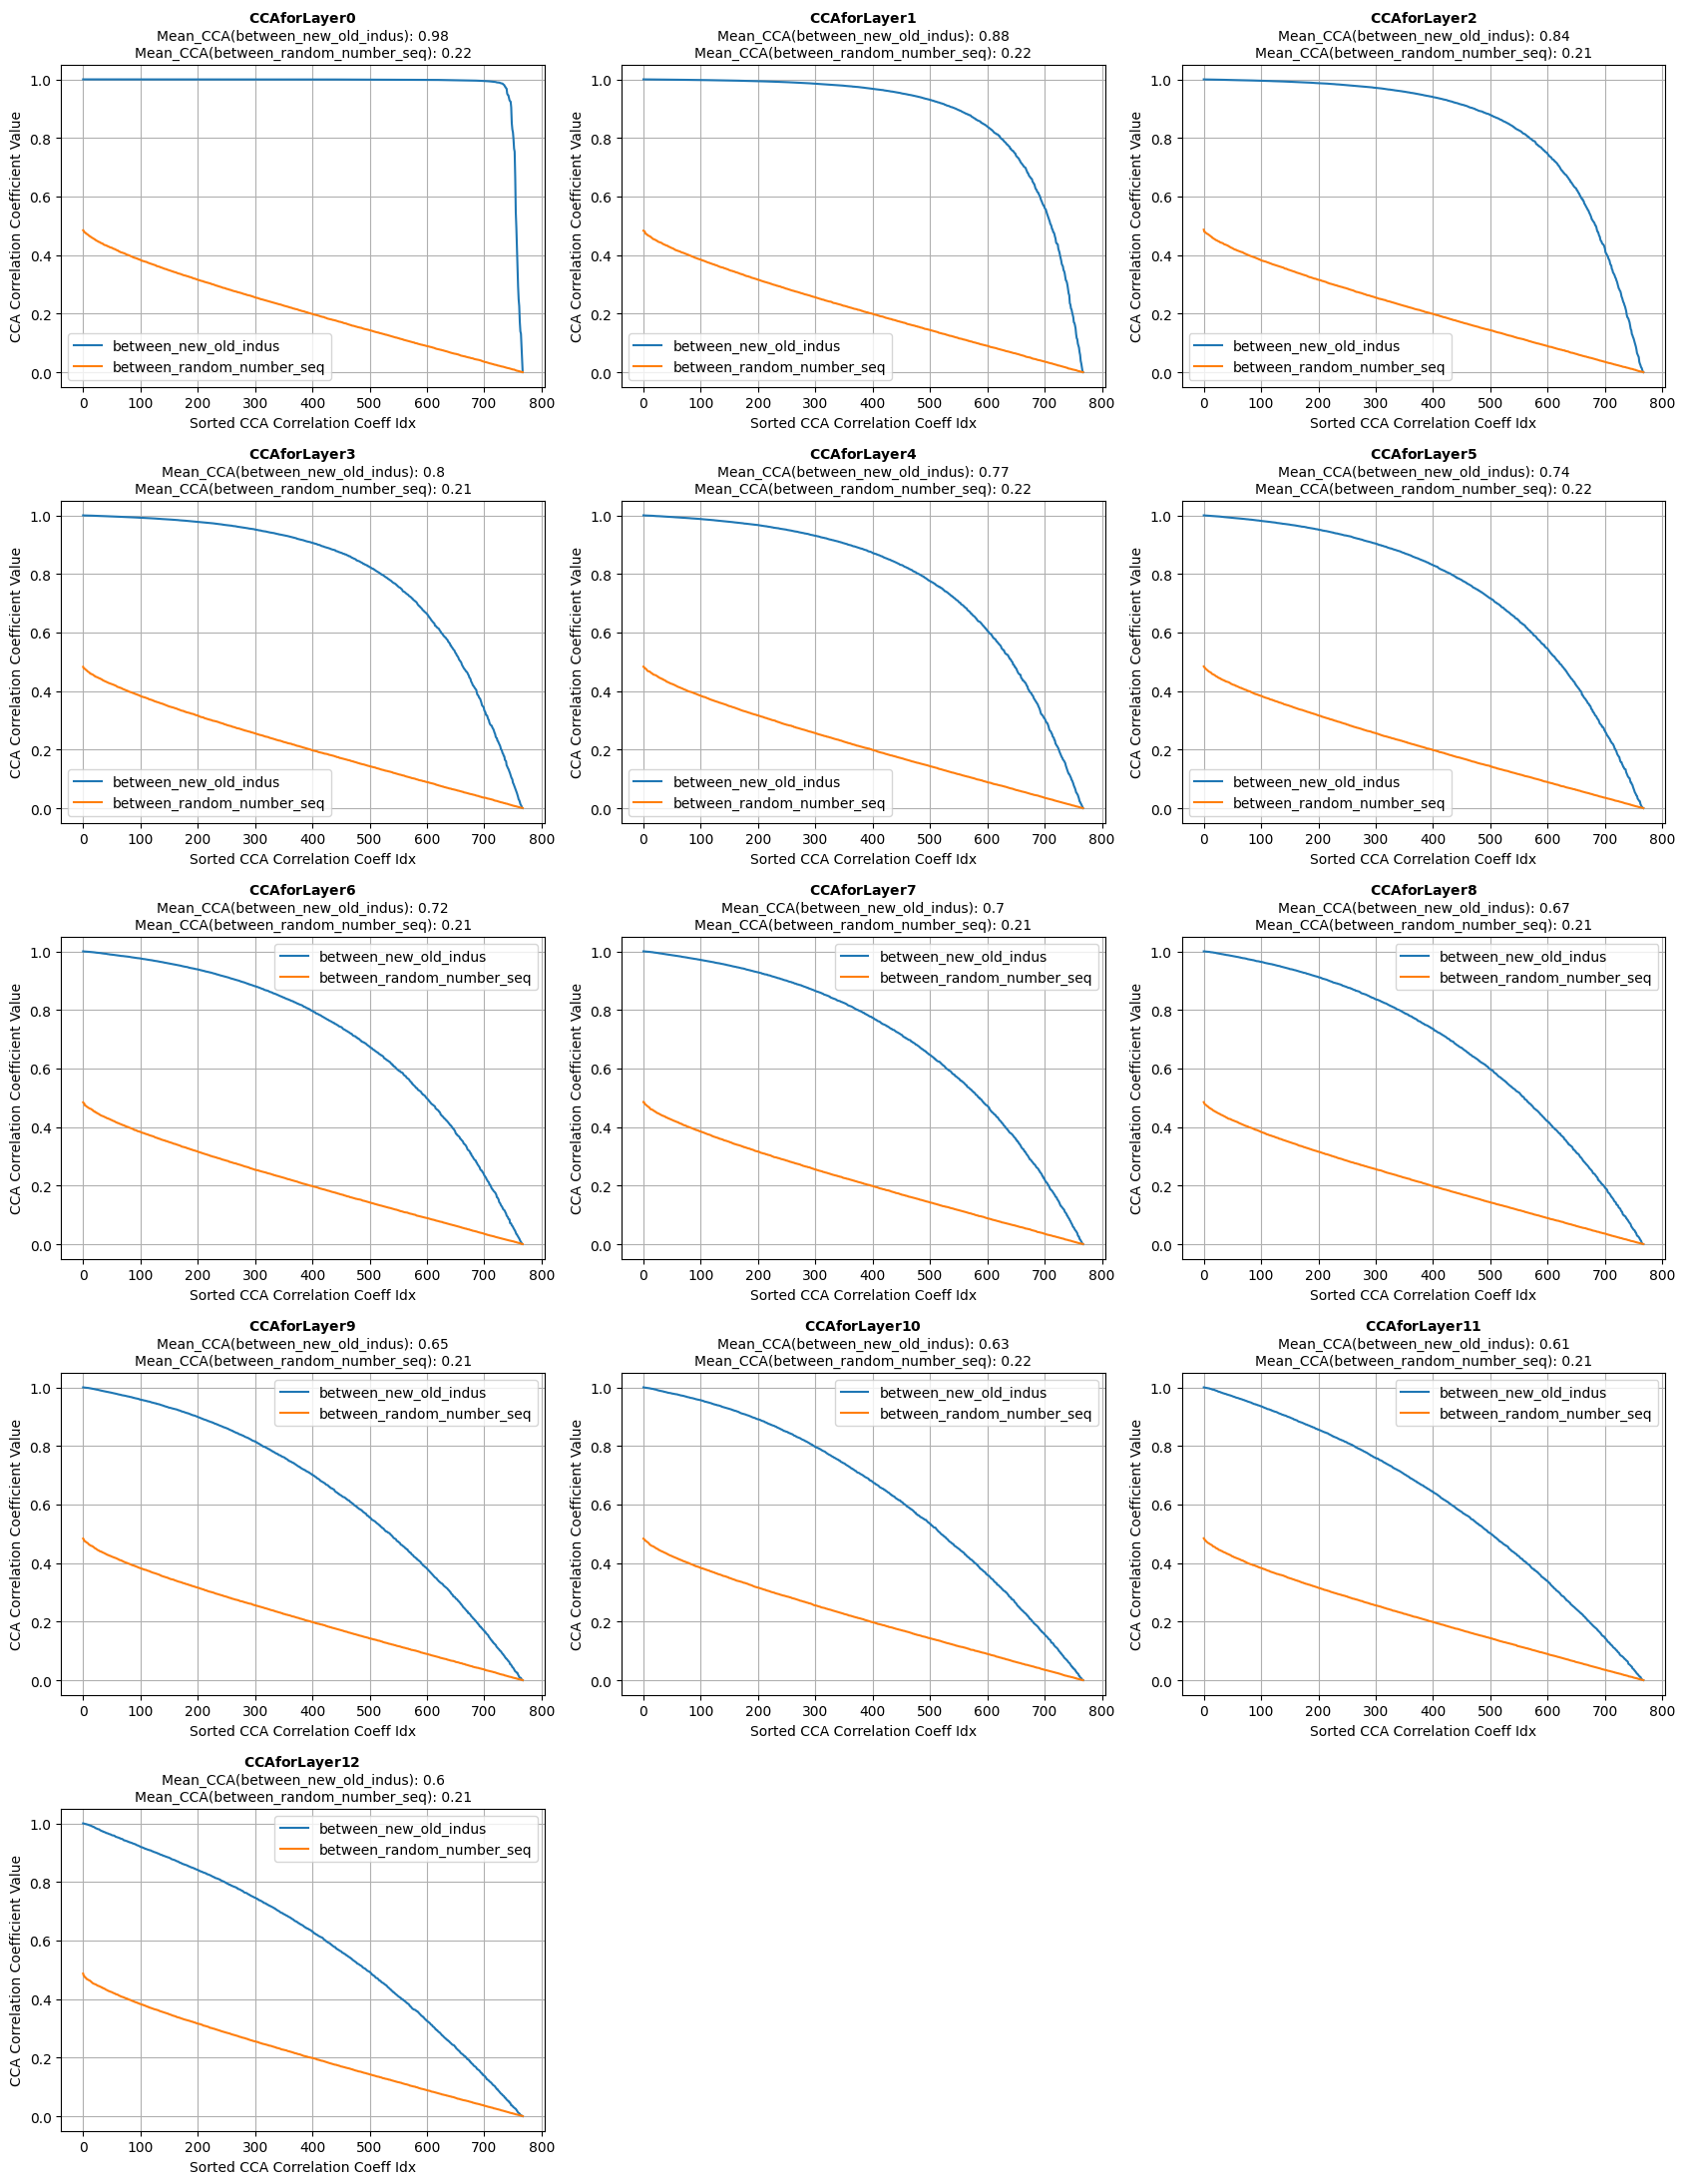

In [9]:
cca_values = {}

# Loop through the layers
old_model_layer_list = embeddings["old_model_name"].keys()
new_model_layer_list = embeddings["new_model_name"].keys()

assert old_model_layer_list == new_model_layer_list, "The layers of the two models do not match"

for layer_number in old_model_layer_list:
    acts1 = embeddings["old_model_name"][layer_number].T.numpy()
    acts2 = embeddings["new_model_name"][layer_number].T.numpy()

    a = np.random.randn(*acts1.shape)
    b = np.random.randn(*acts2.shape)

    results = cca_core.get_cca_similarity(acts1, acts2, epsilon=1e-10, verbose=False)
    baseline = cca_core.get_cca_similarity(a, b, epsilon=1e-10, verbose=False)
    cca_values[layer_number] = {"between_new_old_indus": results, "between_random_number_seq": baseline}

mean_ccas = plot_cca_similarity(cca_values)

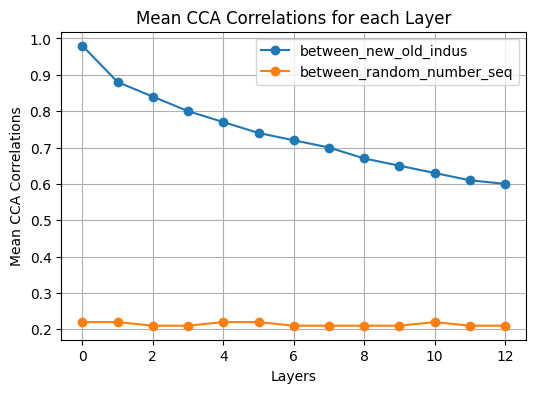

In [12]:
# plotting mean CCA values
plt.figure(figsize=(6, 4))

for label, values in mean_ccas.items():
    plt.plot(values.keys(), values.values(), marker='o', linestyle='-', label=label)

plt.xlabel("Layers")
plt.ylabel("Mean CCA Correlations")
plt.title("Mean CCA Correlations for each Layer")
plt.legend()
plt.grid(True)
plt.show()


# Using SVCCA ( Singular Vector Canonical Correlation Analysis)

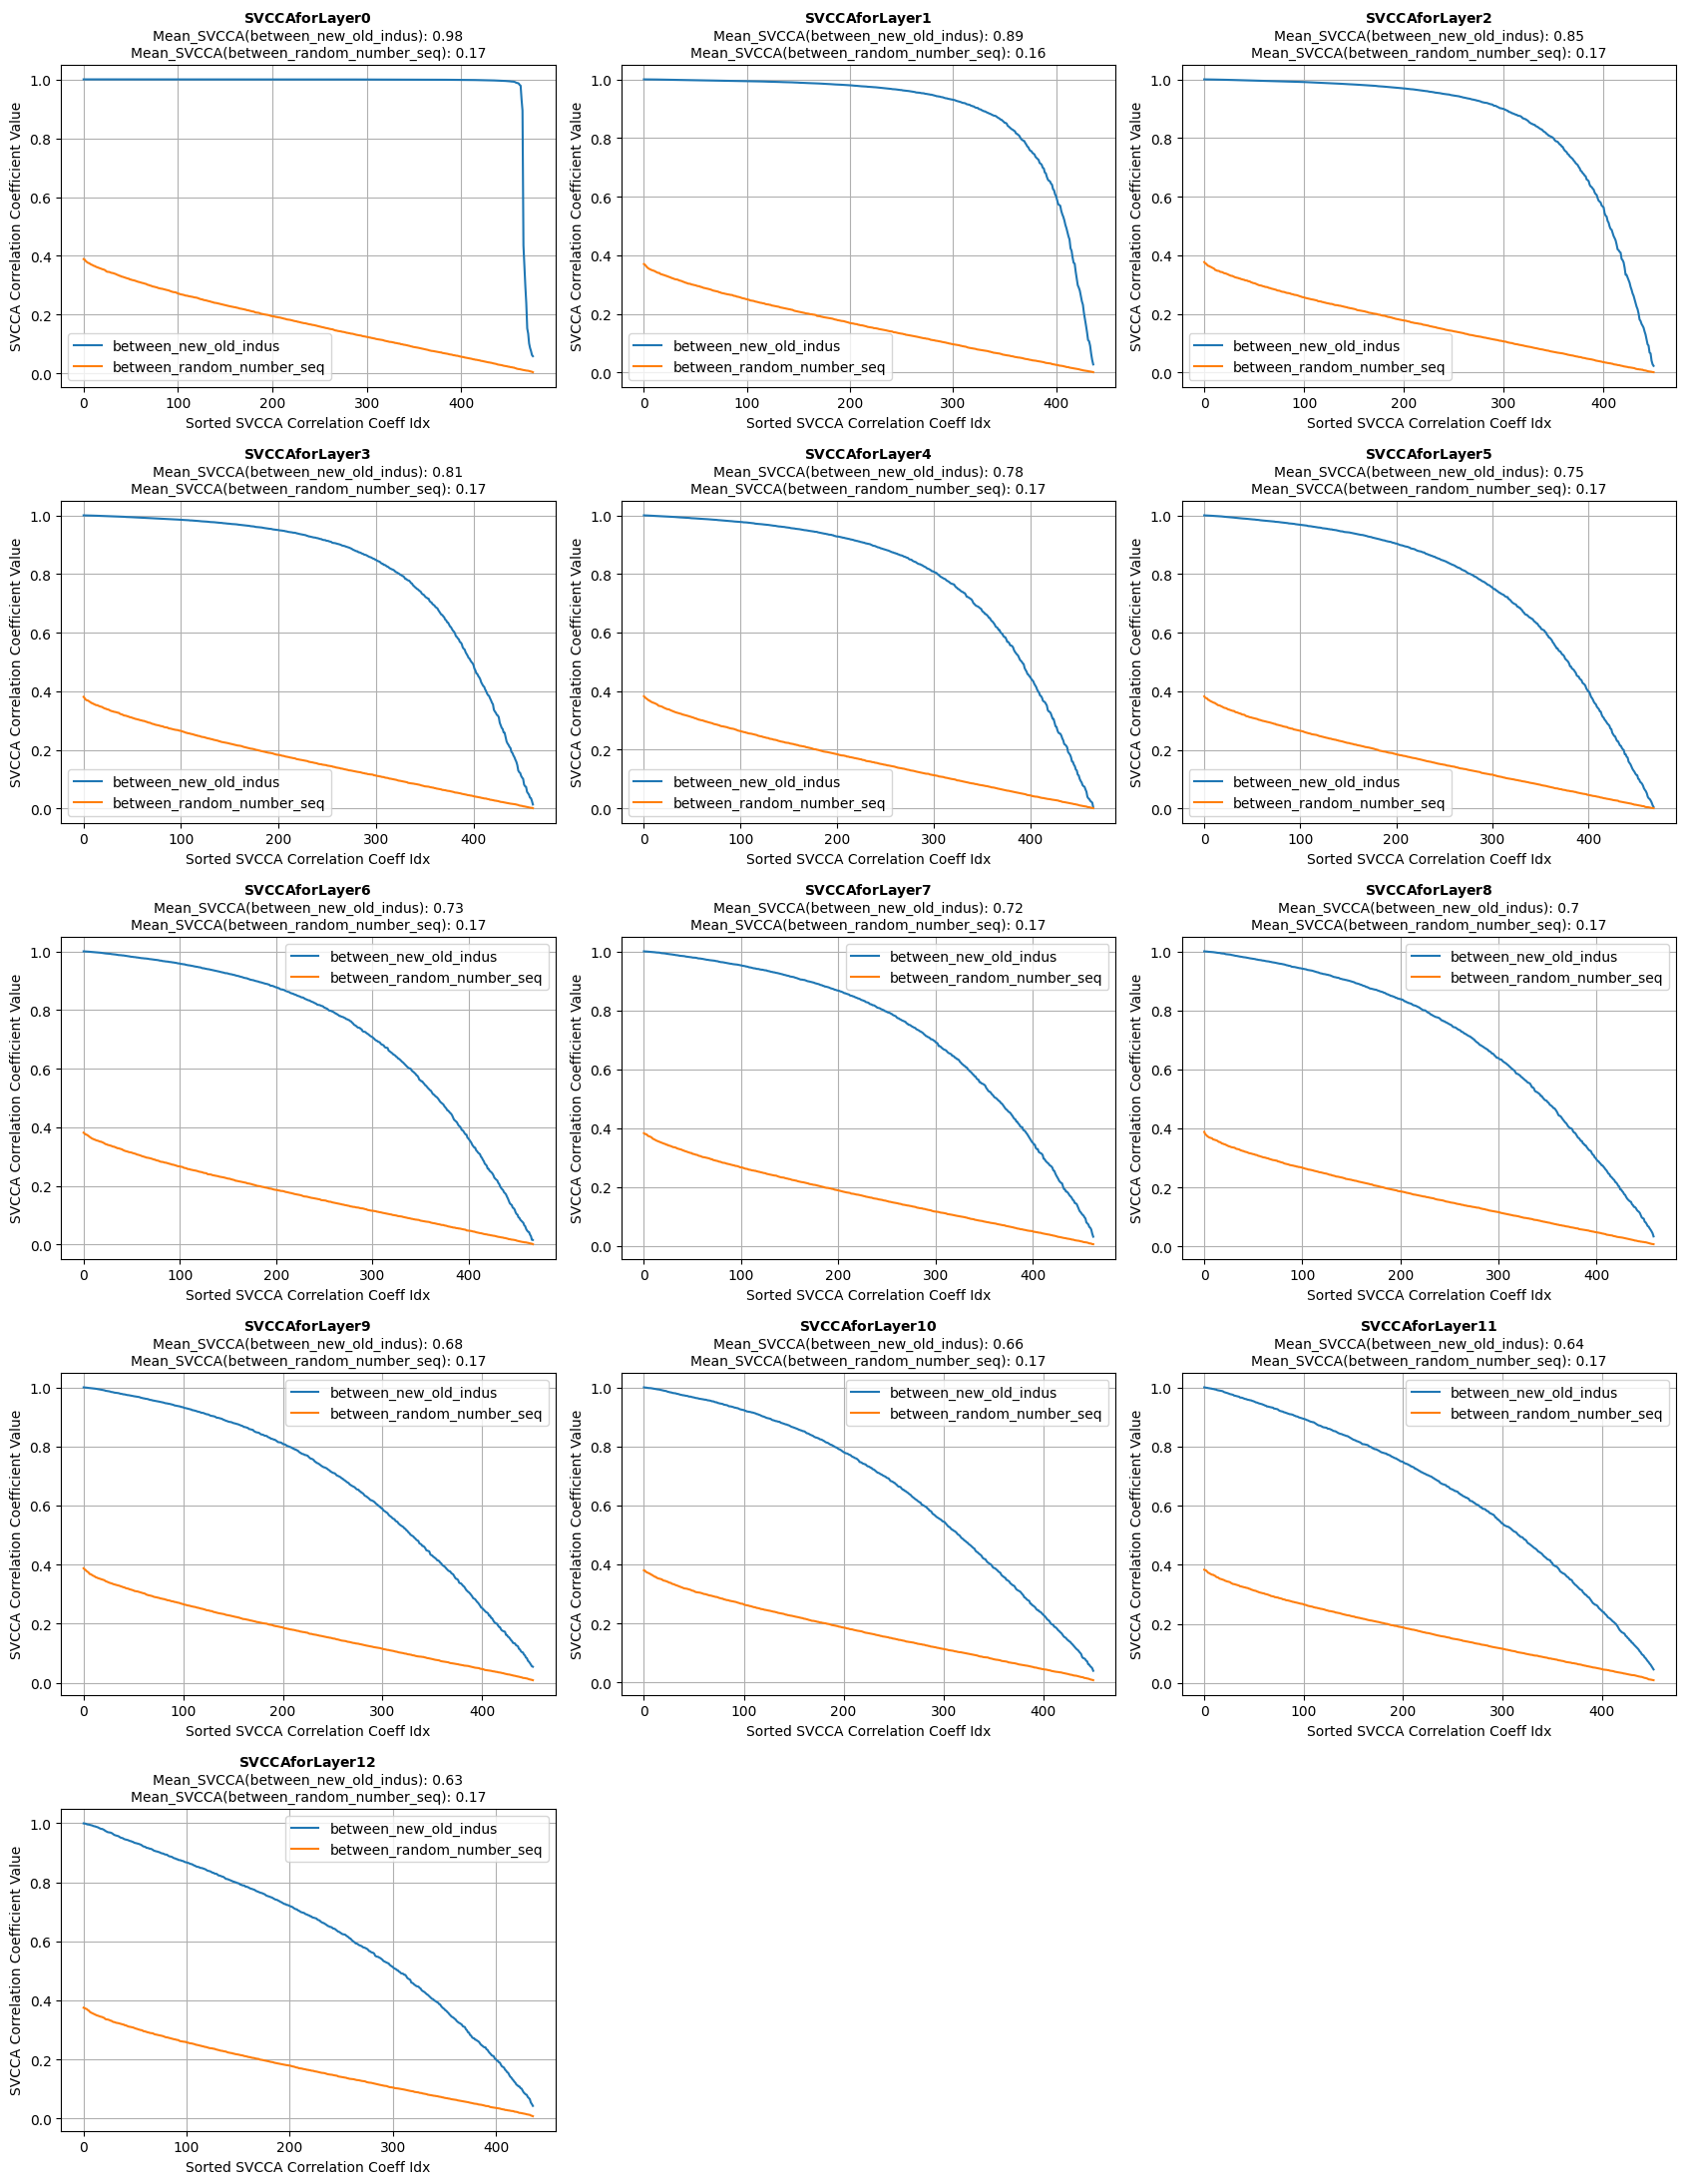

In [13]:
svcca_values = {}

# Loop through the layers
old_model_layer_list = embeddings["old_model_name"].keys()
new_model_layer_list = embeddings["new_model_name"].keys()

assert old_model_layer_list == new_model_layer_list, "The layers of the two models do not match"

for layer_number in old_model_layer_list:
    acts1 = embeddings["old_model_name"][layer_number].T.numpy()
    acts2 = embeddings["new_model_name"][layer_number].T.numpy()


    # Mean subtract activations
    cacts1 = acts1 - np.mean(acts1, axis=1, keepdims=True)
    cacts2 = acts2 - np.mean(acts2, axis=1, keepdims=True)

    # Perform SVD
    U1, s1, V1 = np.linalg.svd(cacts1, full_matrices=False)
    U2, s2, V2 = np.linalg.svd(cacts2, full_matrices=False)

    # find the number of principle component need to explain 90% of variance
    n1 = find_pcomponents_for_variance(s1, 0.9)
    n2 = find_pcomponents_for_variance(s2, 0.9)

    svacts1 = np.dot(s1[:n1]*np.eye(n1), V1[:n1])
    svacts2 = np.dot(s2[:n2]*np.eye(n2), V2[:n2])

    svcca_results = cca_core.get_cca_similarity(svacts1, svacts2, epsilon=1e-10, verbose=False)

    # for baseline
    b1 = np.random.randn(*acts1.shape)
    b2 = np.random.randn(*acts2.shape)
    # Mean subtract baseline activations
    cb1 = b1 - np.mean(b1, axis=0, keepdims=True)
    cb2 = b2 - np.mean(b2, axis=0, keepdims=True)

    # Perform SVD
    Ub1, sb1, Vb1 = np.linalg.svd(cb1, full_matrices=False)
    Ub2, sb2, Vb2 = np.linalg.svd(cb2, full_matrices=False)

    # find the number of principle component need to explain 90% of variance
    _n1 = find_pcomponents_for_variance(s1, 0.9)
    _n2 = find_pcomponents_for_variance(s2, 0.9)

    svb1 = np.dot(sb1[:_n1]*np.eye(_n1), Vb1[:_n1])
    svb2 = np.dot(sb2[:_n2]*np.eye(_n2), Vb2[:_n2])

    svcca_baseline = cca_core.get_cca_similarity(svb1, svb2, epsilon=1e-10, verbose=False)
    
    svcca_values[layer_number] = {"between_new_old_indus": svcca_results, "between_random_number_seq": svcca_baseline}


mean_svcca_values = plot_cca_similarity(svcca_values, factor_name="SVCCA")

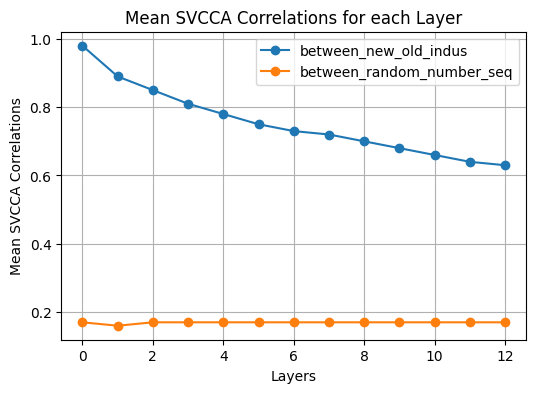

In [14]:
# plotting mean SVCCA values
plt.figure(figsize=(6, 4))

for label, values in mean_svcca_values.items():
    plt.plot(values.keys(), values.values(), marker='o', linestyle='-', label=label)

plt.xlabel("Layers")
plt.ylabel("Mean SVCCA Correlations")
plt.title("Mean SVCCA Correlations for each Layer")
plt.legend()
plt.grid(True)
plt.show()

# Using PWCCA (Projection Weighted Mean of CCA)

In [ ]:
import pwcca

cca_values = {}

# Loop through the layers
old_model_layer_list = embeddings["old_model_name"].keys()
new_model_layer_list = embeddings["new_model_name"].keys()

assert old_model_layer_list == new_model_layer_list, "The layers of the two models do not match"

for layer_number in old_model_layer_list:
    acts1 = embeddings["old_model_name"][layer_number].T.numpy()
    acts2 = embeddings["new_model_name"][layer_number].T.numpy()

    b1 = np.random.randn(*acts1.shape)
    b2 = np.random.randn(*acts2.shape)

    pwcca_mean, w, _ = pwcca.compute_pwcca(acts1, acts2, epsilon=1e-10)
    pwcca_baseline, wb, _ = pwcca.compute_pwcca(b1, b2, epsilon=1e-10)
    print("-"*10)
    print(f"Layer {layer_number}")
    print("Baseline", pwcca_baseline, "and MNIST", pwcca_mean)





----------
Layer {layer_number}
Baseline 0.21751417004354173 and MNIST 0.9968360312052826
----------
Layer {layer_number}
Baseline 0.21715434849797555 and MNIST 0.9830841338719334
----------
Layer {layer_number}
Baseline 0.21709433153158927 and MNIST 0.9631604662833116
----------
Layer {layer_number}
Baseline 0.21753536970172016 and MNIST 0.9490875135572334
----------
Layer {layer_number}
Baseline 0.21743673970164726 and MNIST 0.9401615815641579
----------
Layer {layer_number}
Baseline 0.21757165611379198 and MNIST 0.925269900762097
----------
Layer {layer_number}
Baseline 0.21742460724334303 and MNIST 0.9115950106780744
----------
Layer {layer_number}
Baseline 0.21760327297042842 and MNIST 0.9007873630330868
----------
Layer {layer_number}
Baseline 0.21747582517476483 and MNIST 0.882139113408997
----------
Layer {layer_number}
Baseline 0.21724281449930768 and MNIST 0.8641062907626433
